# Machine Learning - Lab 3 - Logistic Regression

## 1. Setup

### (1a) Imports and config

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, precision_score,
                             recall_score, f1_score, fbeta_score, make_scorer)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'figure.dpi': 100})

RANDOM_STATE = 1

### (1b) Data Loading

In [2]:
bankruptcy_repo = fetch_ucirepo(id=365)

X_raw = bankruptcy_repo.data.features
y_raw = bankruptcy_repo.data.targets

df_full = X_raw.copy()
df_full['bankrupt'] = y_raw[y_raw.columns[0]].astype(int)

# Filtrujemy rok 1 — dane z najwcześniejszego okresu przed bankructwem
df = df_full[df_full['year'] == 1].drop(columns='year').reset_index(drop=True)

print(f"Rok 1: {len(df)} próbek")
print(f"Bankrutów: {df['bankrupt'].sum()} ({100*df['bankrupt'].mean():.1f}%)")
print(f"Zdrowych:  {(df['bankrupt']==0).sum()} ({100*(1-df['bankrupt'].mean()):.1f}%)")
print(f"\nCechy: {df.shape[1]-1}")
df.head()

Rok 1: 7027 próbek
Bankrutów: 271 (3.9%)
Zdrowych:  6756 (96.1%)

Cechy: 64


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A56,A57,A58,A59,A60,A61,A62,A63,A64,bankrupt
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,...,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,...,0.121300,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,...,0.241140,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,...,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,...,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0


### 2. EDA + Missing Values

Cechy z brakami: 49 / 64
Najgorzej uzupełnione cechy:


,n braków,% braków
A37,2740,39.0
A21,1622,23.1
A27,311,4.4
A45,134,1.9
A60,135,1.9
A24,124,1.8
A41,84,1.2
A11,39,0.6
A32,38,0.5
A54,34,0.5


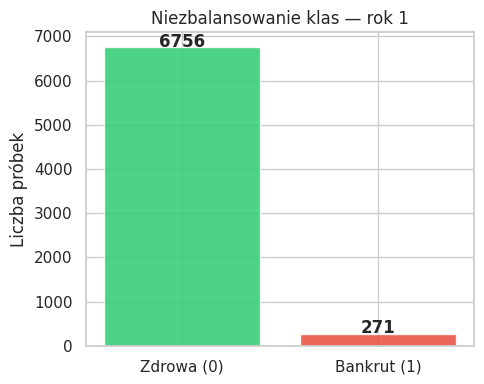


⚠ Silne niezbalansowanie klas: 'accuracy' będzie myląca jako metryka.
  Używamy class_weight='balanced' + metryki precision/recall/F1.


In [3]:
# Braki danych — w zbiorze Bankruptcy są liczne NaN-y
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'n braków': missing, '% braków': missing_pct})
missing_df = missing_df[missing_df['n braków'] > 0].sort_values('% braków', ascending=False)

print(f"Cechy z brakami: {len(missing_df)} / {df.shape[1]-1}")
print(f"Najgorzej uzupełnione cechy:")
display(missing_df.head(10))

# Niezbalansowanie klas — kluczowy kontekst dla regresji logistycznej
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['bankrupt'].value_counts()
bars = ax.bar(['Zdrowa (0)', 'Bankrut (1)'], counts.values,
              color=['#2ecc71', '#e74c3c'], alpha=0.85, edgecolor='white')
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(count), ha='center', fontweight='bold')
ax.set_title('Niezbalansowanie klas — rok 1')
ax.set_ylabel('Liczba próbek')
plt.tight_layout()
plt.show()

print("\n⚠ Silne niezbalansowanie klas: 'accuracy' będzie myląca jako metryka.")
print("  Używamy class_weight='balanced' + metryki precision/recall/F1.")

## 3. Data Split

In [4]:
TARGET = 'bankrupt'
feature_cols = [c for c in df.columns if c != TARGET]

X = df[feature_cols].values
y = df[TARGET].values

# Podział 60/20/20 z zachowaniem proporcji klas
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train_val
)

def load_feature_mapping():
    candidates = [
        Path('feature_name_mapping.json'),
        Path('notebooks/lab3/feature_name_mapping.json'),
    ]
    for p in candidates:
        if p.exists():
            with p.open('r', encoding='utf-8') as f:
                payload = json.load(f)
            return payload.get('mapping', {})
    return {}

feature_mapping = load_feature_mapping()

def feature_label(feature_name, max_desc_len=60):
    desc = feature_mapping.get(feature_name)
    if not desc:
        return feature_name
    if len(desc) > max_desc_len:
        desc = desc[:max_desc_len - 3] + '...'
    return f"{feature_name} - {desc}"

print(f"Train: {X_train.shape}, bankrutów: {y_train.sum()} ({100*y_train.mean():.1f}%)")
print(f"Val:   {X_val.shape}, bankrutów: {y_val.sum()} ({100*y_val.mean():.1f}%)")
print(f"Test:  {X_test.shape}, bankrutów: {y_test.sum()} ({100*y_test.mean():.1f}%)")
print(f"\nZaładowano mapowanie opisów cech: {len(feature_mapping)} pozycji")

Train: (4215, 64), bankrutów: 163 (3.9%)
Val:   (1406, 64), bankrutów: 54 (3.8%)
Test:  (1406, 64), bankrutów: 54 (3.8%)

Załadowano mapowanie opisów cech: 64 pozycji


## 4. Preprocessing (Imputer, Scaler, Model)

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # 1. imputacja median z X_train
    ('scaler',  StandardScaler()),                  # 2. standaryzacja na podstawie X_train
    ('model',   LogisticRegression(                 # 3. model bazowy
        class_weight='balanced',                    # kompensacja niezbalansowania klas
        solver='lbfgs',
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

# fit widzi tylko X_train — imputer i scaler uczą się wyłącznie na danych treningowych
pipeline.fit(X_train, y_train)

# Predykcje na walidacji (do strojenia) i teście (do finalnej oceny)
y_val_pred = pipeline.predict(X_val)
y_val_prob = pipeline.predict_proba(X_val)[:, 1]
y_test_pred_default = pipeline.predict(X_test)
y_test_prob = pipeline.predict_proba(X_test)[:, 1]

print("✓ Pipeline fittowany na X_train.")
print("\nWalidacja (próg=0.5):")
print(classification_report(y_val, y_val_pred, target_names=['Zdrowa (0)', 'Bankrut (1)'], zero_division=0))
print(f"F2 validation (beta=2): {fbeta_score(y_val, y_val_pred, beta=2, zero_division=0):.3f}")

✓ Pipeline fittowany na X_train.

Walidacja (próg=0.5):
              precision    recall  f1-score   support

  Zdrowa (0)       0.98      0.66      0.79      1352
 Bankrut (1)       0.08      0.72      0.14        54

    accuracy                           0.66      1406
   macro avg       0.53      0.69      0.47      1406
weighted avg       0.95      0.66      0.77      1406

F2 validation (beta=2): 0.274


#### Wnioski (baseline)
- model osiąga accuracy = 0.66, metryka nie ma zbyt dużego sensu w takim niezbalansowanym zbiorze, bo gdyby strzelał zawsze w zdrową to byłoby accuracy = 0.96
- `Bankrut (1)` recall = 0.72 - wykrywamy 72% faktycznych bankrutów, precision = 0.08 - tylko 8% firm które model oznaczył jako bankrutów, faktycznie zbankrutowało

## 5. Confusion Matrix

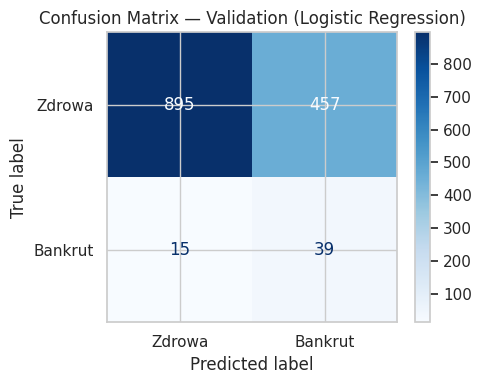

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred,
    display_labels=['Zdrowa', 'Bankrut'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Validation (Logistic Regression)')
plt.tight_layout()
plt.show()

## 6. Weights + Economic interpretation

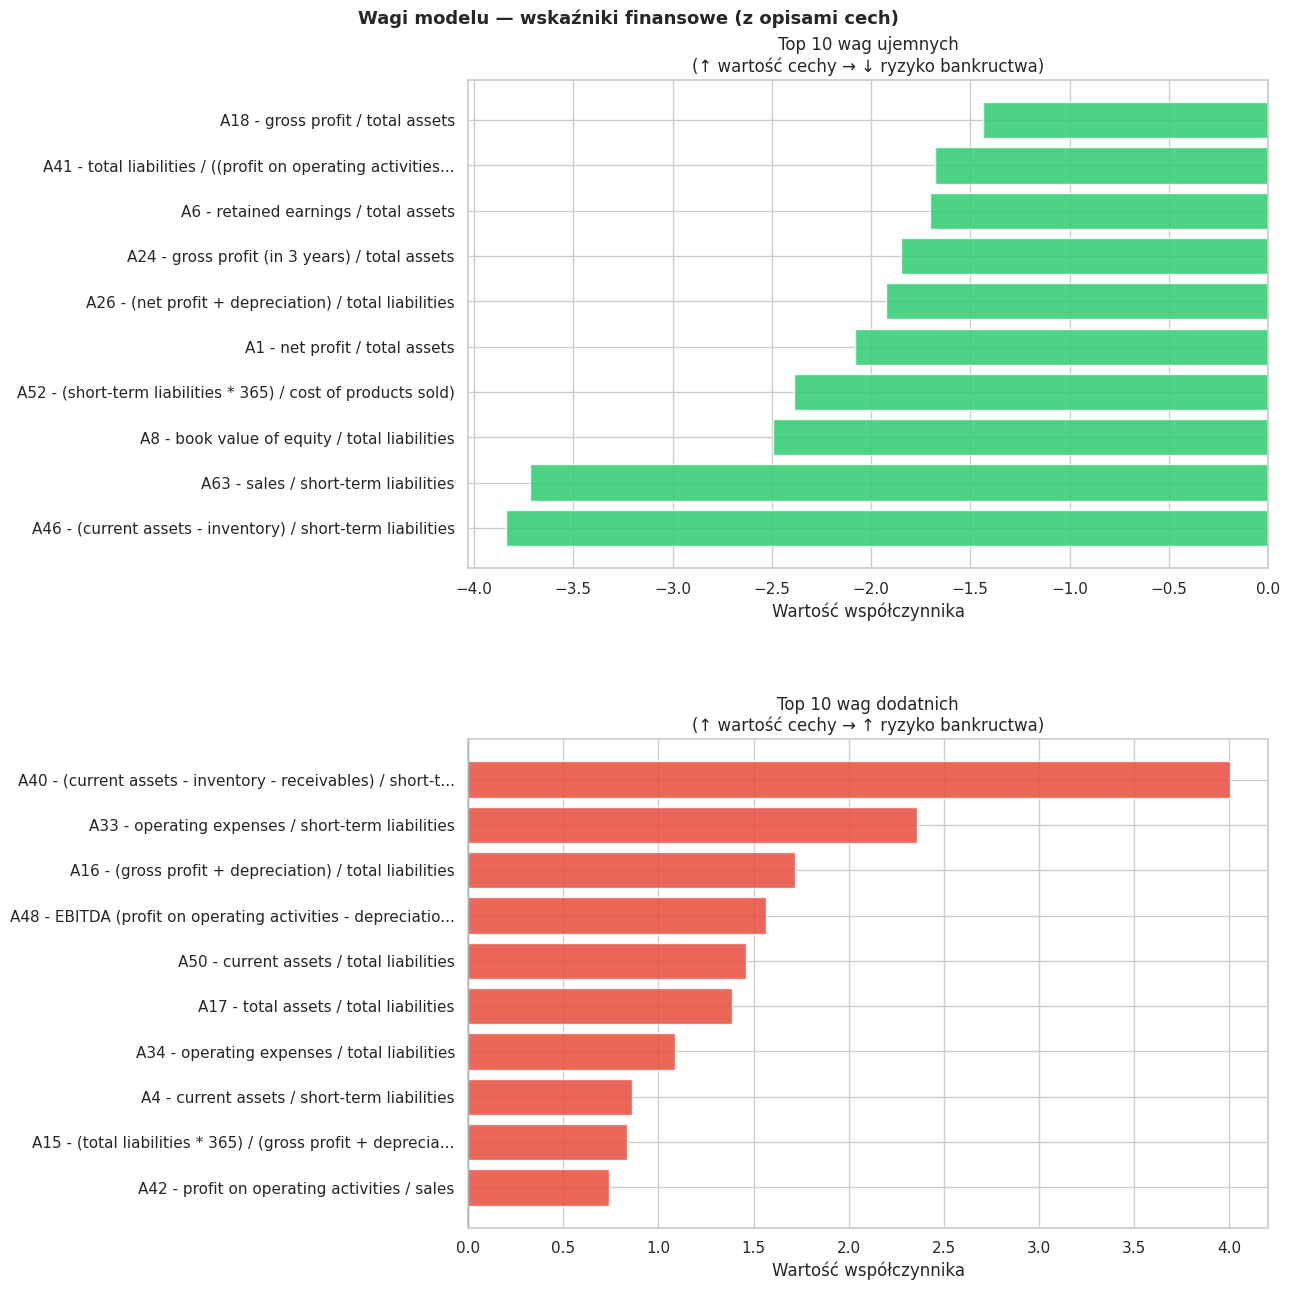

Największe wagi dodatnie (sygnały bankructwa):
cecha                                                                  opis     waga
  A40   (current assets - inventory - receivables) / short-term liabilities 4.002681
  A33                           operating expenses / short-term liabilities 2.358157
  A16                     (gross profit + depreciation) / total liabilities 1.717786
  A48 EBITDA (profit on operating activities - depreciation) / total assets 1.567603
  A50                                    current assets / total liabilities 1.462657

Największe wagi ujemne (sygnały zdrowia finansowego):
cecha                                                    opis      waga
  A46   (current assets - inventory) / short-term liabilities -3.838401
  A63                          sales / short-term liabilities -3.717427
   A8                book value of equity / total liabilities -2.491954
  A52 (short-term liabilities * 365) / cost of products sold) -2.388856
   A1                       

In [7]:
coef_df = pd.DataFrame({
    'cecha': feature_cols,
    'waga': pipeline.named_steps['model'].coef_[0]
})
coef_df['opis'] = coef_df['cecha'].map(feature_mapping).fillna('brak opisu')
coef_df['etykieta'] = coef_df['cecha'].apply(lambda c: feature_label(c, max_desc_len=55))
coef_df = coef_df.sort_values('waga', ascending=True)

fig, axes = plt.subplots(2, 1, figsize=(16, 14))

top_neg = coef_df.head(10)
axes[0].barh(top_neg['etykieta'], top_neg['waga'], color='#2ecc71', alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top 10 wag ujemnych\n(↑ wartość cechy → ↓ ryzyko bankructwa)')
axes[0].set_xlabel('Wartość współczynnika')

top_pos = coef_df.tail(10).sort_values('waga', ascending=True)
axes[1].barh(top_pos['etykieta'], top_pos['waga'], color='#e74c3c', alpha=0.85, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top 10 wag dodatnich\n(↑ wartość cechy → ↑ ryzyko bankructwa)')
axes[1].set_xlabel('Wartość współczynnika')

for ax in axes:
    ax.tick_params(axis='y', labelsize=11)

plt.suptitle('Wagi modelu — wskaźniki finansowe (z opisami cech)', fontsize=13, fontweight='bold')
plt.subplots_adjust(left=0.40, hspace=0.35, top=0.93)
plt.show()

print('Największe wagi dodatnie (sygnały bankructwa):')
print(
    coef_df.tail(5)[['cecha', 'opis', 'waga']]
    .sort_values('waga', ascending=False)
    .to_string(index=False)
)
print('\nNajwiększe wagi ujemne (sygnały zdrowia finansowego):')
print(coef_df.head(5)[['cecha', 'opis', 'waga']].to_string(index=False))

# --- Stabilność znaków wag — 5-fold CV ---
cv_signs = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_coefs = []

for train_idx, _ in cv_signs.split(X_train, y_train):
    fold_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            class_weight='balanced',
            solver='lbfgs',
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ])
    fold_pipe.fit(X_train[train_idx], y_train[train_idx])
    fold_coefs.append(fold_pipe.named_steps['model'].coef_[0])

fold_top_pos_sets = []
fold_top_neg_sets = []
for coefs in fold_coefs:
    s = pd.Series(coefs, index=feature_cols)
    fold_top_pos_sets.append(set(s.nlargest(10).index))
    fold_top_neg_sets.append(set(s.nsmallest(10).index))

# Cechy które w co najmniej jednym foldzie były w top-10 pozytywnych
# i w co najmniej jednym foldzie w top-10 negatywnych
ever_pos = set().union(*fold_top_pos_sets)
ever_neg = set().union(*fold_top_neg_sets)
cross_conflicts = ever_pos & ever_neg

# Cechy które zmieniły znak wagi względem całego X_train
full_coef_series = pd.Series(pipeline.named_steps['model'].coef_[0], index=feature_cols)
sign_changes = []
for feat in feature_cols:
    full_sign = np.sign(full_coef_series[feat])
    fold_signs = [np.sign(coefs[feature_cols.index(feat)]) for coefs in fold_coefs]
    n_opposite = sum(s != full_sign and s != 0 for s in fold_signs)
    if n_opposite > 0:
        sign_changes.append((feat, full_sign, fold_signs, n_opposite))

sign_changes.sort(key=lambda x: -x[3])

print(f"\n--- Stabilność znaków wag (5-fold CV) ---")
print(f"Cechy które zmieniły znak wagi w co najmniej 1 foldzie: {len(sign_changes)} / {len(feature_cols)}")

if sign_changes:
    print("\nPrzykłady (top 5 po liczbie foldów ze zmienionym znakiem):")
    for feat, full_sign, fold_signs, n_opp in sign_changes[:5]:
        sign_str = '+' if full_sign > 0 else '-'
        fold_str = ''.join('+' if s > 0 else ('-' if s < 0 else '0') for s in fold_signs)
        desc = feature_mapping.get(feat, 'brak opisu')[:55]
        print(f"  {feat:5}  pełny zbiór: {sign_str}  foldy: [{fold_str}]  zmian: {n_opp}/5  — {desc}")

print(f"\nCechy w top-10 PO OBU STRONACH w różnych foldach: {len(cross_conflicts)}")
if cross_conflicts:
    for feat in sorted(cross_conflicts):
        pos_count = sum(feat in s for s in fold_top_pos_sets)
        neg_count = sum(feat in s for s in fold_top_neg_sets)
        desc = feature_mapping.get(feat, 'brak opisu')[:55]
        print(f"  ⚠  {feat} — {desc}")
        print(f"       top-10 POS w {pos_count}/5 foldach, top-10 NEG w {neg_count}/5 foldach")
else:
    print("  Brak — każda cecha trzyma tę samą stronę we wszystkich foldach.")

#### Interpretacja ekonomiczna:
- sygnały zdrowia finansowego:
    - A46 (płynne środki / zobowiązania krótkoterminowe) - firmy, które mają dużo funduszy płynnych (nie w ekwipunku), radzą sobie dobrze
    - A63 (sprzedaże / zobowiązania krótkoterminowe) - podobnie jak wyżej
    - A8 (wartość księgowa kapitału własnego / zobowiązania) - wysoki współczynnik świadczy o tym, że zobowiązania są małe w porównaniu z rozmiarem firmy
    - A52 (zobowiązania krótkoterminowe * 365 / koszt spzedawanych produktów) - ciężkie do interpretacji
    - A1 (zysk netto / aktywa) - firmy które są najbardziej rentowne w porównaniu do ich rozmiaru
- sygnały bankructwa:
    - A40 (aktywa płynne bez zapasów i należności / zobowiązania krótkoterminowe) - paradoksalnie wysoka gotówka może sygnalizować upłynnianie aktywów przez firmy w kryzysie, lub multikolinearność z silnymi cechami ujemnymi (A46, A63)
    - A33 (koszty operacyjne / zobowiązania krótkoterminowe) - firma "pali" gotówkę szybciej niż spłaca zobowiązania
    - A16 (zysk brutto + amortyzacja / zobowiązania ogółem) - ciężkie wysoki wskaźnik przy jednoczesnym bankructwie sugeruje że firma generuje przepływy, ale struktura zadłużenia jest niekorzystnado interpretacji - firma generuje przeplywy, ale struktura zobowiązań jest niekorzystna?
    - A48 (EBITDA / aktywa) - Earnings Before Interest, Taxes, Deprececiation, Amortization - firma generuje dużo, ale dużym kosztem
    - A50 (aktywa obrotowe / zobowiązania ogółem) - pozornie dobry wskaźnik płynności z dodatnią wagą — prawdopodobny efekt współliniowości z A46 i A63, które dominują po stronie ujemnej

### 6b. Stabilność wag — walidacja krzyżowa

In [8]:
# Stabilność wag — porównanie top cech między foldami CV
# Cel: sprawdzić, czy interpretacja współczynników nie opiera się na jednym losowym wektorze wag.
# Cecha "stabilna" pojawia się w top-10 w >=4/5 foldów — jej interpretacja jest wiarygodna.
cv_stability = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_top_pos = []
fold_top_neg = []

for train_idx, val_idx in cv_stability.split(X_train, y_train):
    fold_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            class_weight='balanced',
            solver='lbfgs',
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ])
    fold_pipe.fit(X_train[train_idx], y_train[train_idx])
    coefs = fold_pipe.named_steps['model'].coef_[0]
    coef_series = pd.Series(coefs, index=feature_cols)
    fold_top_pos.append(set(coef_series.nlargest(10).index))
    fold_top_neg.append(set(coef_series.nsmallest(10).index))

# Częstość obecności każdej cechy w top-10 przez wszystkie foldy
all_top_pos = pd.Series([feat for s in fold_top_pos for feat in s]).value_counts()
all_top_neg = pd.Series([feat for s in fold_top_neg for feat in s]).value_counts()

N_FOLDS = 5
print(f"Stabilność wag (5-fold CV) — ile razy cecha pojawiła się w top-10 danej strony:")

print(f"\nTop cechy POZYTYWNE (ryzyko bankructwa):")
for feat, cnt in all_top_pos.head(12).items():
    desc = feature_mapping.get(feat, 'brak opisu')[:55]
    bar = '█' * cnt + '░' * (N_FOLDS - cnt)
    stable_marker = ' ✓' if cnt >= 4 else ''
    print(f"  {bar} {cnt}/{N_FOLDS}{stable_marker}  {feat} — {desc}")

print(f"\nTop cechy NEGATYWNE (sygnały zdrowia finansowego):")
for feat, cnt in all_top_neg.head(12).items():
    desc = feature_mapping.get(feat, 'brak opisu')[:55]
    bar = '█' * cnt + '░' * (N_FOLDS - cnt)
    stable_marker = ' ✓' if cnt >= 4 else ''
    print(f"  {bar} {cnt}/{N_FOLDS}{stable_marker}  {feat} — {desc}")

stable_pos = all_top_pos[all_top_pos >= 4].index.tolist()
stable_neg = all_top_neg[all_top_neg >= 4].index.tolist()
unstable_pos = all_top_pos[all_top_pos <= 2].index.tolist()
unstable_neg = all_top_neg[all_top_neg <= 2].index.tolist()

print(f"\nPodsumowanie:")
print(f"  Stabilne pozytywne  (≥4/5): {stable_pos}")
print(f"  Stabilne negatywne  (≥4/5): {stable_neg}")
print(f"  Niestabilne pozytywne (≤2/5): {unstable_pos[:5]} ← interpretacja niepewna")
print(f"  Niestabilne negatywne (≤2/5): {unstable_neg[:5]} ← interpretacja niepewna")

Stabilność wag (5-fold CV) — ile razy cecha pojawiła się w top-10 danej strony:

Top cechy POZYTYWNE (ryzyko bankructwa):
  █████ 5/5 ✓  A16 — (gross profit + depreciation) / total liabilities
  █████ 5/5 ✓  A33 — operating expenses / short-term liabilities
  █████ 5/5 ✓  A50 — current assets / total liabilities
  █████ 5/5 ✓  A40 — (current assets - inventory - receivables) / short-term
  ████░ 4/5 ✓  A48 — EBITDA (profit on operating activities - depreciation) 
  ████░ 4/5 ✓  A4 — current assets / short-term liabilities
  ████░ 4/5 ✓  A42 — profit on operating activities / sales
  ████░ 4/5 ✓  A15 — (total liabilities * 365) / (gross profit + depreciatio
  ████░ 4/5 ✓  A17 — total assets / total liabilities
  ███░░ 3/5  A39 — profit on sales / sales
  ███░░ 3/5  A34 — operating expenses / total liabilities
  ██░░░ 2/5  A2 — total liabilities / total assets

Top cechy NEGATYWNE (sygnały zdrowia finansowego):
  █████ 5/5 ✓  A46 — (current assets - inventory) / short-term liabilities
  

### 7. Classification Threshold Impact

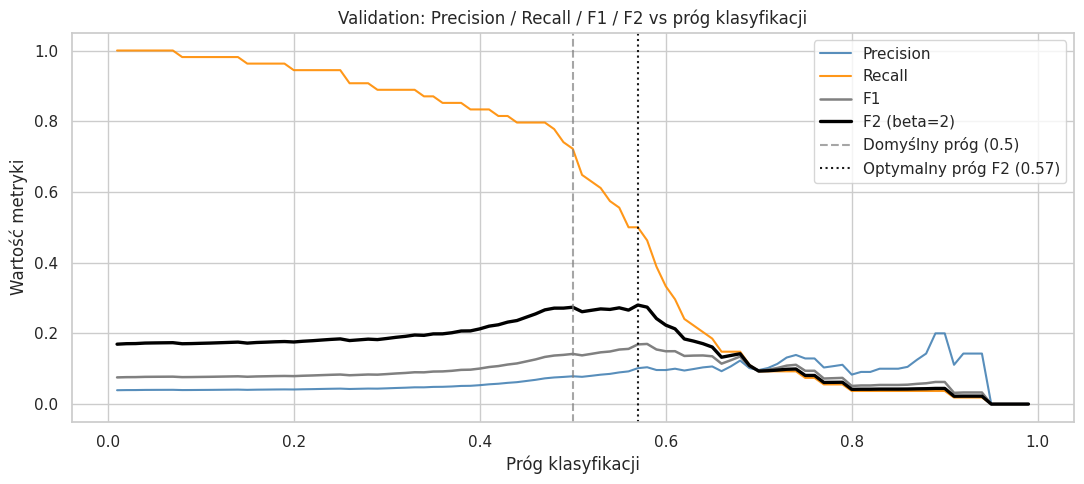

Zbiór                      Próg  Precision     Recall         F1         F2
------------------------------------------------------------------------------
Validation (t=0.50)        0.50      0.079      0.722      0.142      0.274
Validation (best_t)        0.57      0.102      0.500      0.169      0.280
Test (t=0.50)              0.50      0.068      0.630      0.123      0.237
Test (best_t z val)        0.57      0.090      0.463      0.150      0.253

Test (próg dobrany na walidacji):
              precision    recall  f1-score   support

  Zdrowa (0)       0.97      0.81      0.89      1352
 Bankrut (1)       0.09      0.46      0.15        54

    accuracy                           0.80      1406
   macro avg       0.53      0.64      0.52      1406
weighted avg       0.94      0.80      0.86      1406



In [9]:
thresholds = np.linspace(0.01, 0.99, 99)
precisions, recalls, f1s, f2s = [], [], [], []

for t in thresholds:
    y_val_t = (y_val_prob >= t).astype(int)
    precisions.append(precision_score(y_val, y_val_t, zero_division=0))
    recalls.append(recall_score(y_val, y_val_t, zero_division=0))
    f1s.append(f1_score(y_val, y_val_t, zero_division=0))
    f2s.append(fbeta_score(y_val, y_val_t, beta=2, zero_division=0))

# Dobór progu robimy na walidacji i optymalizujemy F2 (większy nacisk na recall)
best_t = thresholds[int(np.argmax(f2s))]

plt.figure(figsize=(11, 5))
plt.plot(thresholds, precisions, label='Precision', color='steelblue', alpha=0.9)
plt.plot(thresholds, recalls,    label='Recall',    color='darkorange', alpha=0.9)
plt.plot(thresholds, f1s,        label='F1', color='gray', linewidth=1.8)
plt.plot(thresholds, f2s,        label='F2 (beta=2)', color='black', linewidth=2.4)
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='Domyślny próg (0.5)')
plt.axvline(best_t, color='black', linestyle=':', alpha=0.9, label=f'Optymalny próg F2 ({best_t:.2f})')
plt.xlabel('Próg klasyfikacji')
plt.ylabel('Wartość metryki')
plt.title('Validation: Precision / Recall / F1 / F2 vs próg klasyfikacji')
plt.legend()
plt.tight_layout()
plt.show()

def evaluate_at_threshold(y_true, y_prob, threshold):
    y_hat = (y_prob >= threshold).astype(int)
    return {
        'precision': precision_score(y_true, y_hat, zero_division=0),
        'recall': recall_score(y_true, y_hat, zero_division=0),
        'f1': f1_score(y_true, y_hat, zero_division=0),
        'f2': fbeta_score(y_true, y_hat, beta=2, zero_division=0),
    }

rows = [
    ('Validation (t=0.50)', 0.50, y_val, y_val_prob),
    ('Validation (best_t)', best_t, y_val, y_val_prob),
    ('Test (t=0.50)', 0.50, y_test, y_test_prob),
    ('Test (best_t z val)', best_t, y_test, y_test_prob),
]

print(f"{'Zbiór':22} {'Próg':>8} {'Precision':>10} {'Recall':>10} {'F1':>10} {'F2':>10}")
print('-' * 78)
for label, threshold, y_true, y_prob in rows:
    metrics = evaluate_at_threshold(y_true, y_prob, threshold)
    print(
        f"{label:22} {threshold:>8.2f} {metrics['precision']:>10.3f} "
        f"{metrics['recall']:>10.3f} {metrics['f1']:>10.3f} {metrics['f2']:>10.3f}"
    )

# Finalna ocena na teście przy progu dobranym na walidacji
y_test_pred_best_t = (y_test_prob >= best_t).astype(int)
print('\nTest (próg dobrany na walidacji):')
print(classification_report(y_test, y_test_pred_best_t, target_names=['Zdrowa (0)', 'Bankrut (1)'], zero_division=0))

#### Wnioski:
- wykres pokazuje, że trade-off między precision a recall nie jest banalny, istnieją przedziały w których spada zarówno precision i recall.
- Przy progu 0.0, model markuje wszystkie firmy jako bankrutów, więc nie przeoczy żadnego.
- F2 z beta=2 uzyskuje najlepszy wynik dla progu 0.57, podobnie jak wskaźnik F1, jednak przy przesunięciu progu z 0.50 na 0.57:
    - recall spada z 63% na 46.3% - model przeoczy większość bankrutów
    - precision rośnie z 6.8% do 9.0% - nieznaczna poprawa
    - F2 rośnie z 0.237 do 0.253

- wybór odpowiedniego wskaźnika i progu zależy od celów biznesowych firmy, w celu wybrania poprawnego wskaźnika i progu należy rozważyć jaki koszt przyniesie firmie pominięcie bankruta, a jaki koszt przyniesie oznaczenie zdrowej firmy jako bankruta.

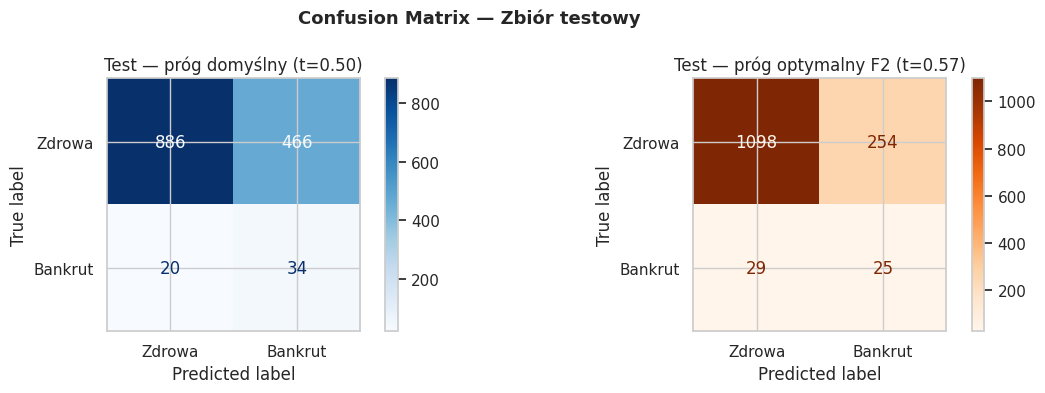

Próg                         TP    FP     TN    FN    Recall  Precision   FN (pominięci)
-------------------------------------------------------------------------------------
t=0.50                       34   466    886    20     0.630      0.068               20
t=0.57 (F2 z val)            25   254   1098    29     0.463      0.090               29

TP = prawdziwe bankruty wykryte  |  FN = bankruty pominięte (koszt!)
FP = zdrowe firmy błędnie oznaczone jako bankrut  |  TN = zdrowe poprawnie


In [10]:
# Macierze pomyłek — zbiór testowy: próg domyślny (0.5) vs optymalny (best_t z walidacji)
y_test_pred_05 = (y_test_prob >= 0.5).astype(int)
y_test_pred_best = (y_test_prob >= best_t).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred_05,
    display_labels=['Zdrowa', 'Bankrut'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Test — próg domyślny (t=0.50)')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred_best,
    display_labels=['Zdrowa', 'Bankrut'],
    cmap='Oranges', ax=axes[1]
)
axes[1].set_title(f'Test — próg optymalny F2 (t={best_t:.2f})')

plt.suptitle('Confusion Matrix — Zbiór testowy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Podsumowanie: kluczowe liczby dla obu progów
print(f"{'Próg':25} {'TP':>5} {'FP':>5} {'TN':>6} {'FN':>5}  {'Recall':>8} {'Precision':>10} {'FN (pominięci)':>16}")
print('-' * 85)
for label, y_pred in [(f't=0.50', y_test_pred_05), (f't={best_t:.2f} (F2 z val)', y_test_pred_best)]:
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"{label:25} {tp:>5} {fp:>5} {tn:>6} {fn:>5}  {recall:>8.3f} {precision:>10.3f} {fn:>16}")
print()
print("TP = prawdziwe bankruty wykryte  |  FN = bankruty pominięte (koszt!)")
print("FP = zdrowe firmy błędnie oznaczone jako bankrut  |  TN = zdrowe poprawnie")

## 8. Impact of the C parameter: L1 vs L2

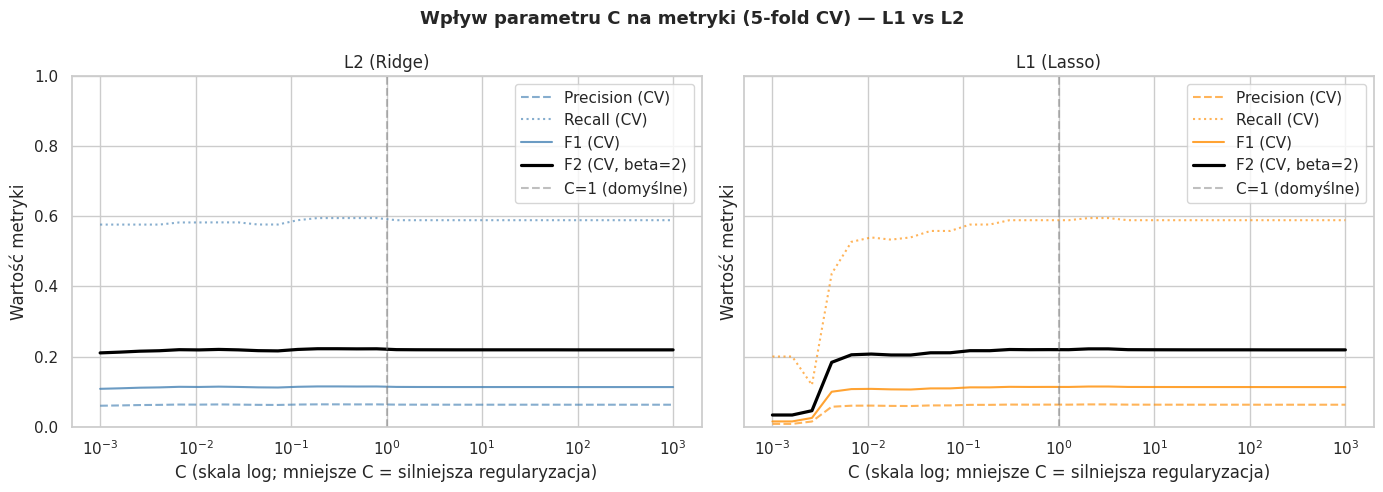

                                   L2 (Ridge)     L1 (Lasso)
--------------------------------------------------------------
Najlepsze C (max F2 CV)                0.3039         3.2903
Max F2 CV                               0.222          0.222

Finalna ocena na teście (C z CV + próg z walidacji):


,model,C (CV),"threshold (val, F2)",precision_test,recall_test,f1_test,f2_test
1,L1 (Lasso),3.2903,0.53,0.0689,0.537,0.1221,0.2276
0,L2 (Ridge),0.3039,0.53,0.0686,0.537,0.1216,0.2269


In [11]:
Cs = np.logspace(-3, 3, 30)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
    'f2': make_scorer(fbeta_score, beta=2, zero_division=0),
}

# Jawna konfiguracja regularyzacji (sklearn >= 1.8 API: l1_ratio zamiast penalty)
# L2 (Ridge): l1_ratio=0  — kary proporcjonalne do kwadratu wag, żadna waga nie jest zerowana
# L1 (Lasso): l1_ratio=1  — kary proporcjonalne do |wag|, automatycznie zeruje nieistotne cechy
regularization_configs = [
    ('l2', 0, 'L2 (Ridge)', 'steelblue'),
    ('l1', 1, 'L1 (Lasso)', 'darkorange'),
]

res = {
    'l2': {'precision': [], 'recall': [], 'f1': [], 'f2': []},
    'l1': {'precision': [], 'recall': [], 'f1': [], 'f2': []},
}

for C in Cs:
    for reg_name, l1_ratio, _, _ in regularization_configs:
        m = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                C=C,
                l1_ratio=l1_ratio,         # 0 = L2 (Ridge), 1 = L1 (Lasso)
                solver='saga',             # saga obsługuje zarówno L1 jak i L2
                class_weight='balanced',
                max_iter=5000,
                tol=1e-3,
                random_state=RANDOM_STATE
            )),
        ])
        scores = cross_validate(m, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
        for metric in ['precision', 'recall', 'f1', 'f2']:
            res[reg_name][metric].append(scores[f'test_{metric}'].mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (reg_name, _, title, color) in zip(axes, regularization_configs):
    ax.semilogx(Cs, res[reg_name]['precision'], '--', color=color, alpha=0.65, label='Precision (CV)')
    ax.semilogx(Cs, res[reg_name]['recall'], ':', color=color, alpha=0.65, label='Recall (CV)')
    ax.semilogx(Cs, res[reg_name]['f1'], '-', color=color, alpha=0.8, label='F1 (CV)')
    ax.semilogx(Cs, res[reg_name]['f2'], '-', color='black', linewidth=2.3, label='F2 (CV, beta=2)')
    ax.axvline(1.0, color='gray', linestyle='--', alpha=0.5, label='C=1 (domyślne)')
    ax.set_xlabel('C (skala log; mniejsze C = silniejsza regularyzacja)')
    ax.set_ylabel('Wartość metryki')
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.legend()

plt.suptitle('Wpływ parametru C na metryki (5-fold CV) — L1 vs L2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_C_l2 = Cs[int(np.argmax(res['l2']['f2']))]
best_C_l1 = Cs[int(np.argmax(res['l1']['f2']))]

print(f"{'':30} {'L2 (Ridge)':>14} {'L1 (Lasso)':>14}")
print('-' * 62)
print(f"{'Najlepsze C (max F2 CV)':30} {best_C_l2:>14.4f} {best_C_l1:>14.4f}")
print(f"{'Max F2 CV':30} {max(res['l2']['f2']):>14.3f} {max(res['l1']['f2']):>14.3f}")

# Finalna ocena na teście: C z CV, próg dobrany na walidacji (F2)
def find_best_threshold_f2(y_true, y_prob, threshold_grid=None):
    if threshold_grid is None:
        threshold_grid = np.linspace(0.01, 0.99, 99)
    scores = [fbeta_score(y_true, (y_prob >= t).astype(int), beta=2, zero_division=0) for t in threshold_grid]
    return threshold_grid[int(np.argmax(scores))]

final_rows = []
for reg_name, l1_ratio, label, _ in regularization_configs:
    best_C = best_C_l2 if reg_name == 'l2' else best_C_l1
    final_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            C=best_C,
            l1_ratio=l1_ratio,         # 0 = L2 (Ridge), 1 = L1 (Lasso)
            solver='saga',
            class_weight='balanced',
            max_iter=5000,
            tol=1e-3,
            random_state=RANDOM_STATE
        )),
    ])
    final_model.fit(X_train, y_train)

    val_prob = final_model.predict_proba(X_val)[:, 1]
    best_t_model = find_best_threshold_f2(y_val, val_prob)

    test_prob = final_model.predict_proba(X_test)[:, 1]
    test_metrics = evaluate_at_threshold(y_test, test_prob, best_t_model)

    final_rows.append({
        'model': label,
        'C (CV)': best_C,
        'threshold (val, F2)': best_t_model,
        'precision_test': test_metrics['precision'],
        'recall_test': test_metrics['recall'],
        'f1_test': test_metrics['f1'],
        'f2_test': test_metrics['f2'],
    })

final_df = pd.DataFrame(final_rows).sort_values('f2_test', ascending=False)
print('\nFinalna ocena na teście (C z CV + próg z walidacji):')
display(final_df.round(4))

#### Interpretacja wpływu parametru C:

- **L2 (Ridge)** jest praktycznie niewrażliwy na wartość C — wszystkie metryki pozostają
płaskie przez cały zakres od 10⁻³ do 10³. Recall utrzymuje się stale ~0.58, F2 ~0.21.
    - regularyzacja L2 nie zmienia istotnie charakteru modelu — wagi maleją proporcjonalnie, ale żadna cecha nie jest eliminowana, więc model zachowuje się podobnie niezależnie od siły regularyzacji.

- **L1 (Lasso)** Przy bardzo małym C (silna regularyzacja, C < 0.01) model jest zdegenerowany — większość wag wyzerowana, recall ~0 i F2 ~0.
    - pomiędzy 10^-3 i 10^-2  metryki gwałtownie rosną wraz z "odmrażaniem" kolejnych cech, osiągając plateau przy C ≈ 0.01. 

**Porównanie końcowe:**

Oba modele po tuningu CV osiągają niemal identyczne wyniki na teście:
- F2 ≈ 0.227 dla L1 (C=3.29) i ≈ 0.227 dla L2 (C=0.30)
- Recall identyczny: 53.7% dla obu
- Próg optymalny identyczny: 0.53

Pomimo że L1 wymaga C aż 10× większego niż L2 żeby osiągnąć ten sam wynik
(mniejsza regularyzacja = więcej niezerowych wag), efekt końcowy jest taki sam.
Sugeruje to że dla tego zbioru regularyzacja typu (L1 vs L2) ma mniejsze znaczenie
niż dobór progu klasyfikacji — co jest głównym dźwignią jakości w problemach
z silnie niezbalansowanymi klasami.